In [21]:
import pandas as pd

filename="D:\PES study\Statistic_PES_sem1\graded\project\weodataset.csv"
df_raw = pd.read_csv(filename, encoding='latin1')

selected_codes = ['NGDP_RPCH', 'NID_NGDP', 'PCPIPCH', 'TX_RPCH']
df_filtered = df_raw[df_raw['WEO Subject Code'].isin(selected_codes)].copy()

# 3. TRANSPOSE THE DATA (Melt and Pivot)
# Identify columns that represent years (1980 - 2024)
year_cols = [col for col in df_filtered.columns if col.isdigit()]

# Melt from wide format (years as columns) to long format
df_melted = df_filtered.melt(
    id_vars=['WEO Subject Code'],
    value_vars=year_cols,
    var_name='Year',
    value_name='Value'
)

# Pivot to get indicators as columns and years as rows
df_processed = df_melted.pivot(index='Year', columns='WEO Subject Code', values='Value')

# 4. DATA CLEANING
# Remove commas and convert strings to floats (handling typical IMF formatting)
df_processed = df_processed.map(lambda x: str(x).replace(',', '') if pd.notnull(x) else x)
df_processed = df_processed.astype(float)

# Sort by year (index)
df_processed.index = df_processed.index.astype(int)
df_processed = df_processed.sort_index()

# 5. RENAMING COLUMNS
rename_map = {
    'NGDP_RPCH': 'GDP_Growth',
    'NID_NGDP': 'Investment',
    'PCPIPCH': 'Inflation',
    'TX_RPCH': 'Export'
}
df_processed.rename(columns=rename_map, inplace=True)

# --- DATA UNDERSTANDING TASKS ---

print("--- 1. DATA TYPES ---")
# Identifies numerical (continuous) and time-series nature
print(df_processed.dtypes)

print(f"\n--- 2. DIMENSIONS ---")
n_obs, n_vars = df_processed.shape
print(f"Number of observations: {n_obs}")
print(f"Number of variables: {n_vars}")

print(f"\n--- 3. TARGET VARIABLE ---")
print("Target Variable: GDP_Growth")

print(f"\n--- 4. DATASET PREVIEW ---")
print(df_processed.tail())

# Save for downstream analysis if needed
# df_processed.to_csv('final_processed_data.csv')

--- 1. DATA TYPES ---
WEO Subject Code
GDP_Growth    float64
Investment    float64
Inflation     float64
Export        float64
dtype: object

--- 2. DIMENSIONS ---
Number of observations: 45
Number of variables: 4

--- 3. TARGET VARIABLE ---
Target Variable: GDP_Growth

--- 4. DATASET PREVIEW ---
WEO Subject Code  GDP_Growth  Investment  Inflation  Export
Year                                                       
2020                  -5.778      28.922      6.165  -6.383
2021                   9.690      32.116      5.506  19.516
2022                   7.609      33.619      6.653   9.453
2023                   9.191      33.362      5.361   0.531
2024                   6.460      33.412      4.668   4.684


In [3]:
import numpy as np

# 2. Descriptive Stats
stats_summary = df_processed.describe().T
stats_summary['variance'] = df_processed.var()
stats_summary['IQR'] = stats_summary['75%'] - stats_summary['25%']

# 3. Outlier Function
def detect_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data < lower_bound) | (data > upper_bound)]

print("Descriptive Statistics:\n", stats_summary)
for col in df_processed.columns:
    print("Outliers in",{col},":", detect_outliers(df_processed[col]).values)

Descriptive Statistics:
                   count       mean       std     min     25%     50%     75%  \
WEO Subject Code                                                               
GDP_Growth         45.0   6.021489  2.637545  -5.778   4.777   6.454   7.860   
Investment         45.0  29.700756  6.135187  19.727  24.921  30.096  33.619   
Inflation          45.0   7.366289  2.927422   3.414   4.769   6.736   9.433   
Export             45.0   8.155600  7.574315  -6.383   4.130   7.258  12.514   

                     max   variance    IQR  
WEO Subject Code                            
GDP_Growth         9.690   6.956645  3.083  
Investment        41.951  37.640518  8.698  
Inflation         13.481   8.569797  4.664  
Export            27.319  57.370253  8.384  
Outliers in {'GDP_Growth'} : [-5.778]
Outliers in {'Investment'} : []
Outliers in {'Inflation'} : []
Outliers in {'Export'} : [27.034 27.319]


Text(0.5, 1.0, 'GDP GrowthRate Distribution')

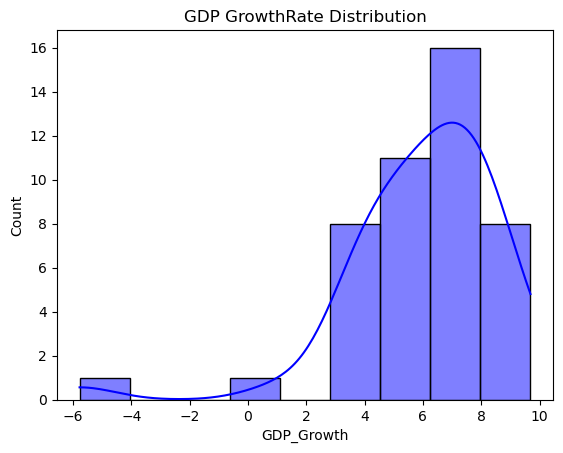

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# DISTRIBUTION PLOTS
# Histogram of Target Variable
sns.histplot(df_processed['GDP_Growth'], kde=True, color='blue')
plt.title('GDP GrowthRate Distribution')


Text(0.5, 1.0, 'Boxplot of Economic Indicators')

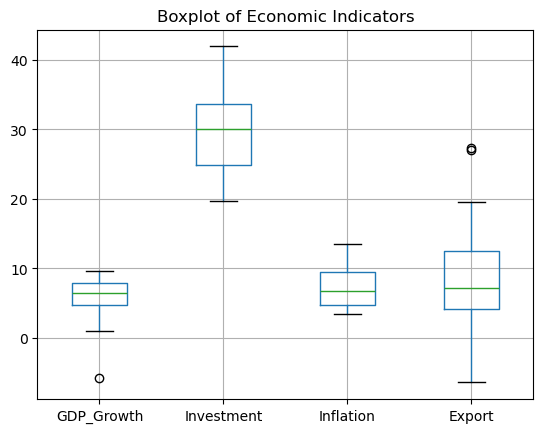

In [5]:

# Boxplot for Outliers and Comparisons
df_processed.boxplot()
plt.title('Boxplot of Economic Indicators')



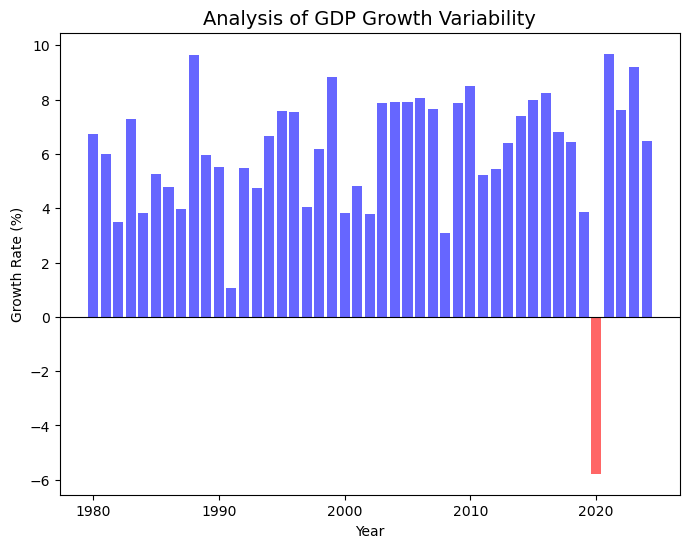

In [6]:
# Create a color list: green for positive, red for negative
colors = ['red' if x < 0 else 'blue' for x in df_processed['GDP_Growth']]

plt.figure(figsize=(8, 6))
plt.bar(df_processed.index, df_processed['GDP_Growth'], color=colors,alpha=0.6)

plt.axhline(0, color='black', linewidth=0.8) # Add a baseline at 0
plt.title('Analysis of GDP Growth Variability', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')

plt.show()

Text(0.5, 1.0, 'Trend of Indicators (1980-2024)')

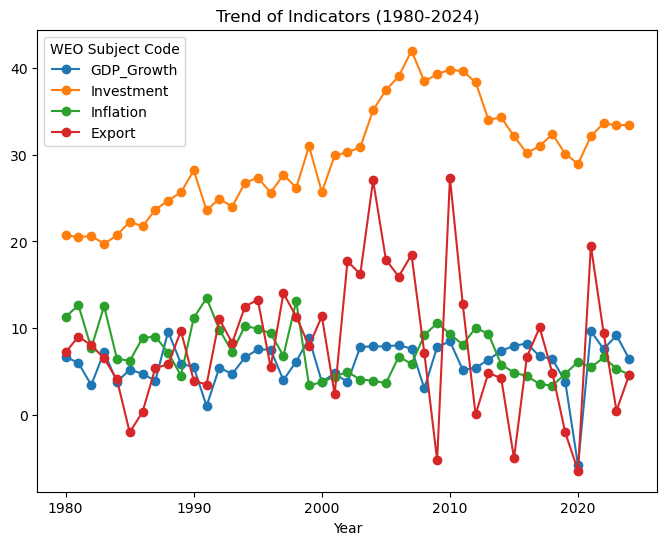

In [7]:
# 3. RELATIONSHIP AND TREND PLOTS
# Line Plot (Time Series Trends)
df_processed.plot(figsize=(8, 6), marker='o')
plt.title('Trend of Indicators (1980-2024)')

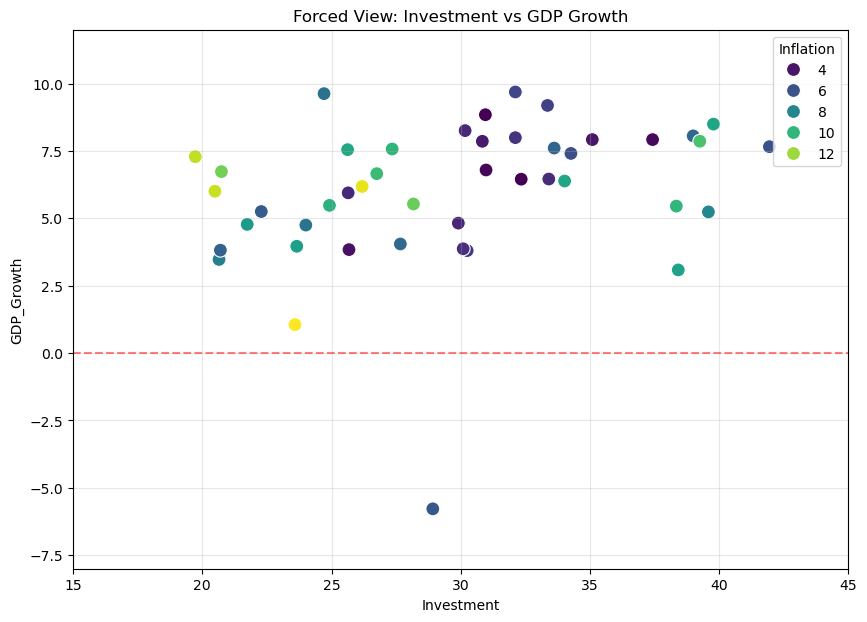

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a clear figure
plt.figure(figsize=(10, 7))

# 2. Plot with explicit limits to 'Force' the view
# We use x=Investment (27.2) and y=GDP_Growth (-5.778)
sns.scatterplot(data=df_processed, x='Investment', y='GDP_Growth', 
                hue='Inflation', palette='viridis', s=100)

# 3. SET EXPLICIT BOUNDARIES 
# Your Investment goes from ~20 to 42. Your Growth goes from -6 to 10.
plt.xlim(15, 45) 
plt.ylim(-8, 12)

# 4. ADD A REFERENCE LINE
# This helps you see exactly where 'negative' starts
plt.axhline(0, color='red', linestyle='--', alpha=0.5)

# 5. ANNOTATE THE POINT (The ultimate test)
# This will draw an arrow pointing exactly where the 2020 point should be
# plt.annotate('2020 Outlier', xy=(27.2, -5.778), xytext=(30, -4),
#              arrowprops=dict(facecolor='black', shrink=0.05))

plt.title("Forced View: Investment vs GDP Growth")
plt.grid(True, alpha=0.3)
plt.show()

Text(0.5, 1.0, 'Indicators Comparison (Last 10 Years)')

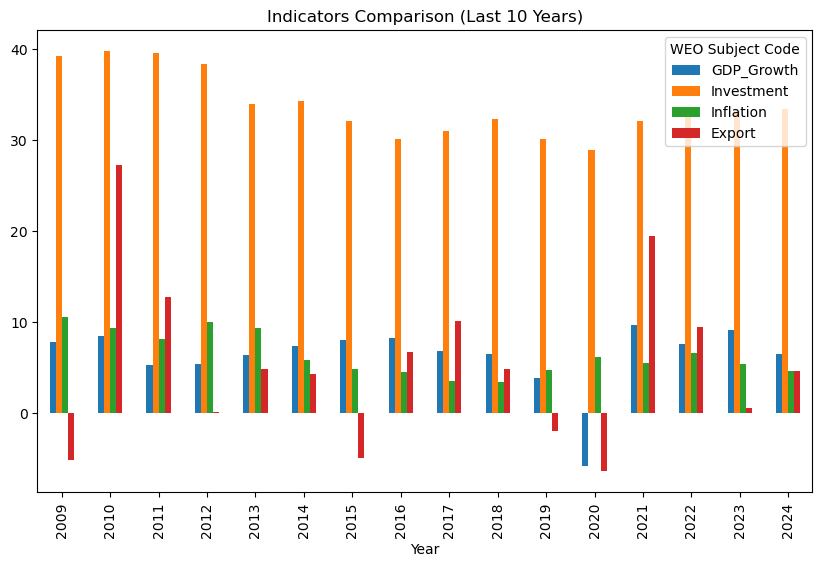

In [9]:
# Grouped Bar Chart (Last 16 Years Comparison)
df_processed.tail(16).plot(kind='bar', figsize=(10,6))
plt.title('Indicators Comparison (Last 10 Years)')

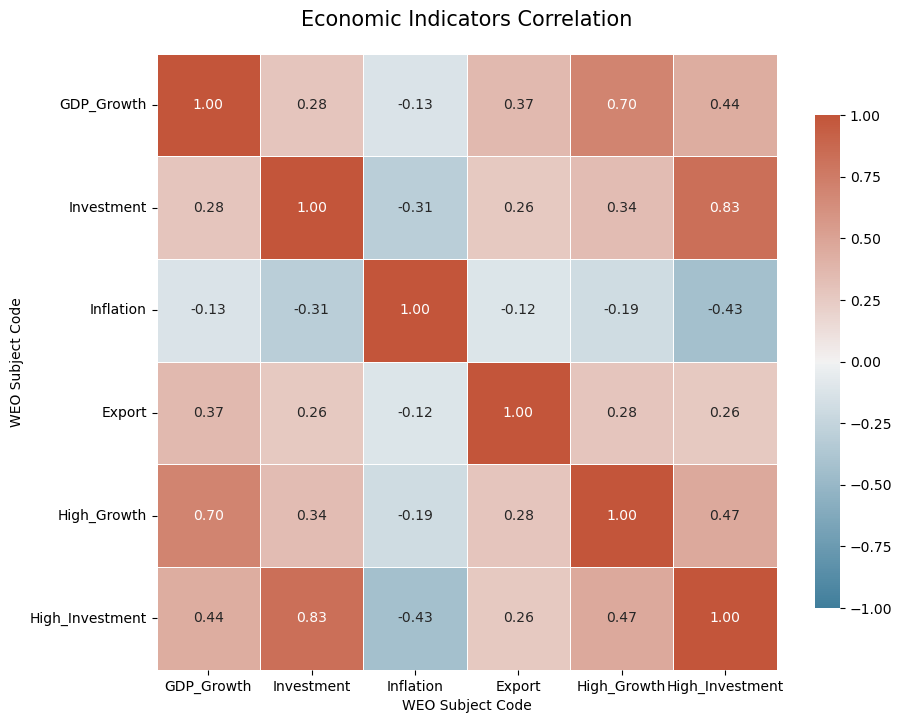

In [19]:
# 4. MULTIVARIATE & STATISTICAL PLOTS
# Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate correlation, ensuring only numbers are used
corr = df_processed.corr(numeric_only=True)

# 2. Create the custom palette again
cmap = sns.diverging_palette(230, 20, as_cmap=True)

plt.figure(figsize=(10, 8))

# 3. The 'vmin', 'vmax', and 'center' arguments are CRITICAL for professionalism
sns.heatmap(corr, 
            annot=True, 
            fmt=".2f", 
            cmap=cmap, 
            vmin=-1,    # Forces the scale to start at -1
            vmax=1,     # Forces the scale to end at 1
            center=0,   # Ensures 0 is the neutral gray/white color
            linewidths=.5, 
            cbar_kws={"shrink": .8})

plt.title('Economic Indicators Correlation', fontsize=15, pad=20)
plt.show()

Text(0.5, 1.0, 'Covariance Heatmap')

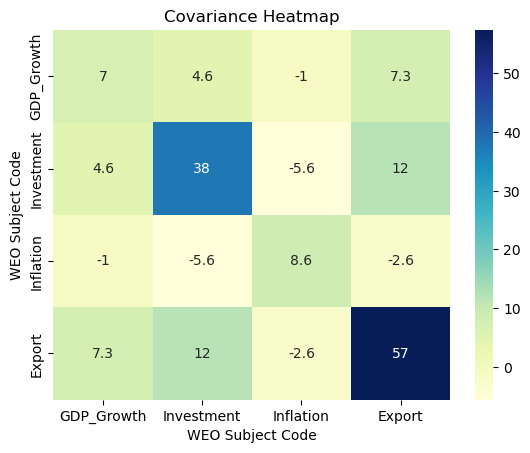

In [22]:
# Covariance Heatmap
cov=df_processed.cov(numeric_only=True)
sns.heatmap(cov,annot=True, cmap='YlGnBu')
plt.title('Covariance Heatmap')


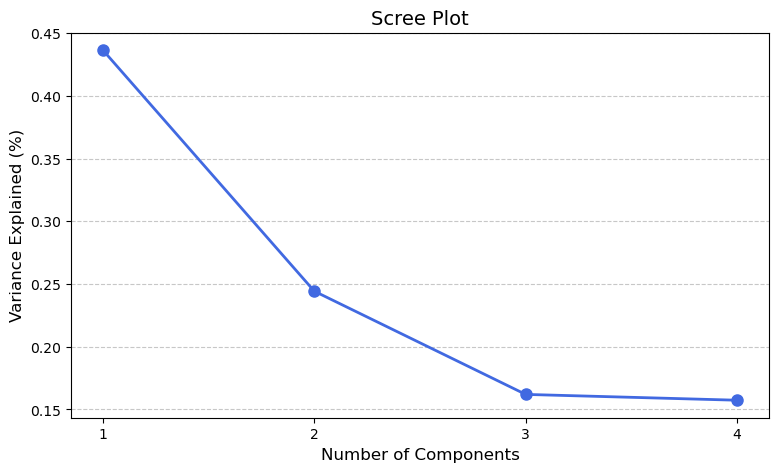

In [33]:
import matplotlib.pyplot as plt

# Step 1: Pick the columns for your M.Tech project
features = ['GDP_Growth', 'Investment', 'Inflation', 'Export']

# Step 2: Define the Scaler
scaler = StandardScaler()

# Step 3: CREATE x_scaled (This is where it is defined)
x_scaled = scaler.fit_transform(df_processed[features])
pca_full = PCA().fit(x_scaled)
exp_var = pca_full.explained_variance_ratio_

plt.figure(figsize=(9, 5))
# The 'o-' creates the line and the dots
plt.plot(range(1, 5), exp_var, 'o-', linewidth=2, color='royalblue', markersize=8)

plt.title('Scree Plot', fontsize=14)
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Variance Explained (%)', fontsize=12)
plt.xticks(range(1, 5))
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()


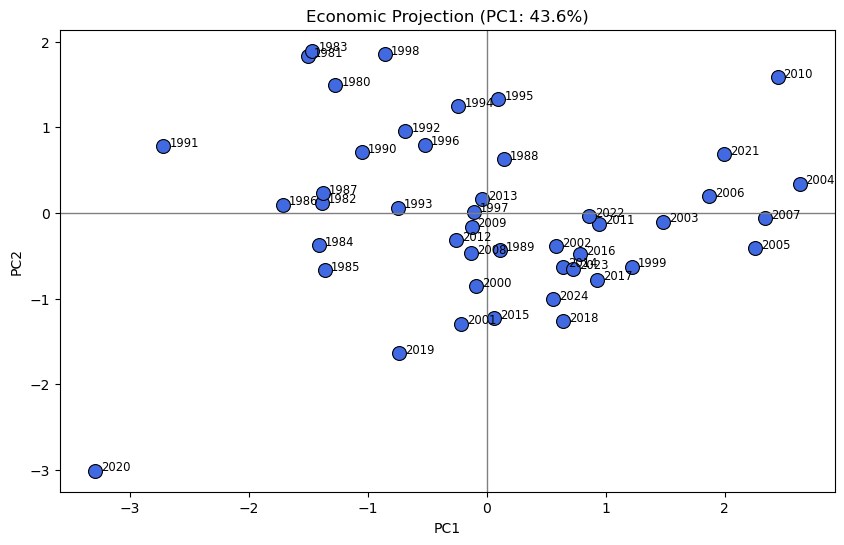

In [30]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Step 1: Pick the columns for your M.Tech project
features = ['GDP_Growth', 'Investment', 'Inflation', 'Export']

# Step 2: Define the Scaler
scaler = StandardScaler()

# Step 3: CREATE x_scaled (This is where it is defined)
x_scaled = scaler.fit_transform(df_processed[features])
# 1. You transformed your scaled data into the 2D space
pc_results = pca_2d.fit_transform(x_scaled)

# Step 2: DEFINE pca_df (Convert those numbers into a labeled table)
pca_df = pd.DataFrame(
    data = pc_results, 
    columns = ['PC1', 'PC2']
)

# Step 3: Attach the years so Seaborn knows what to label
pca_df['Year'] = df_processed.index

# Create the plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', s=100, color='royalblue', edgecolor='black')

# Simple loop for labels (Seaborn handles the axes and grid cleanly)
for line in range(0, pca_df.shape[0]):
     plt.text(pca_df.PC1[line]+0.05, pca_df.PC2[line], pca_df.Year[line], 
              horizontalalignment='left', size='small', color='black')

plt.axhline(0, color='grey', lw=1); plt.axvline(0, color='grey', lw=1)
plt.title(f"Economic Projection (PC1: {pca_2d.explained_variance_ratio_[0]:.1%})")
plt.show()

In [41]:
# 2. Define Medians as Thresholds
median_gdp = df_processed['GDP_Growth'].median()
median_inv = df_processed['Investment'].median()

# 3. Create Event Flags
df_processed['High_Growth'] = df_processed['GDP_Growth'] > median_gdp
df_processed['High_Investment'] = df_processed['Investment'] > median_inv

# 4. Calculate Probabilities
total = len(df_processed)
p_a = df_processed['High_Growth'].sum() / total
p_b = df_processed['High_Investment'].sum() / total
p_a_and_b = len(df_processed[(df_processed['High_Growth']) & (df_processed['High_Investment'])]) / total

# 5. Conditional Probabilities
p_a_given_b = p_a_and_b / p_b  # P(High Growth | High Investment)
p_b_given_a = p_a_and_b / p_a  # P(High Investment | High Growth)

# 6. Bayes Theorem Verification
bayes_val = (p_b_given_a * p_a) / p_b

print("Basic Probability of High Growth:", round(p_a*100,2),"%")
print("Conditional Probability (Growth | Invest):", round(p_a_given_b*100,2),"%")
print("Bayes Verification:", round(bayes_val*100,2),"%")

# Calculate P(High Investment | Low Growth)
p_b_given_not_a = len(df_processed[(~df_processed['High_Growth']) & (df_processed['High_Investment'])]) / len(df_processed[~df_processed['High_Growth']])

# Calculate the Likelihood Ratio
likelihood_ratio = p_b_given_a / p_b_given_not_a

print(f"Likelihood Ratio: {likelihood_ratio:.2f}")

Basic Probability of High Growth: 48.89 %
Conditional Probability (Growth | Invest): 72.73 %
Bayes Verification: 72.73 %
Likelihood Ratio: 2.79


In [50]:
from scipy import stats

# 1. Confidence Interval for Mean GDP Growth
data =df_processed['GDP_Growth']
mean, sem = np.mean(data), stats.sem(data)
ci = stats.t.interval(0.95, len(data)-1, loc=mean, scale=sem)
lower, upper = ci
print(f"95% Confidence Interval for Mean GDP Growth: ({lower:.2f}%, {upper:.2f}%)")

# 2. Hypothesis Testing (T-test)
high_inv = df_processed[df_processed['Investment'] >df_processed['Investment'].median()]['GDP_Growth']
low_inv = df_processed[df_processed['Investment'] <= df_processed['Investment'].median()]['GDP_Growth']
t_stat, p_val = stats.ttest_ind(high_inv, low_inv)

print(f"T-test P-value: {p_val:.4f}")
significance = "Significant" if p_val < 0.05 else "Not Significant"
print(f"Result is statistically {significance} at the 5% level.")


95% Confidence Interval for Mean GDP Growth: (5.23%, 6.81%)
T-test P-value: 0.0023
Result is statistically Significant at the 5% level.


In [51]:
# 1. Prepare the Groups
# Divide investment into 3 equal-sized tiers (Low, Medium, High)
df_processed['Inv_Tier'] = pd.qcut(df_processed['Investment'], 3, labels=['Low', 'Medium', 'High'])

low_tier = df_processed[df_processed['Inv_Tier'] == 'Low']['GDP_Growth']
medium_tier = df_processed[df_processed['Inv_Tier'] == 'Medium']['GDP_Growth']
high_tier = df_processed[df_processed['Inv_Tier'] == 'High']['GDP_Growth']

# 2. Perform One-Way ANOVA
f_stat, p_val_anova = stats.f_oneway(low_tier, medium_tier, high_tier)

print(f"ANOVA F-statistic: {f_stat:.4f}")
print(f"ANOVA P-value: {p_val_anova:.4f}")

# 3. Interpretation
if p_val_anova < 0.05:
    print("Conclusion: At least one investment tier has a significantly different mean GDP growth.")
else:
    print("Conclusion: There is no statistically significant difference in mean growth across the three tiers.")

ANOVA F-statistic: 1.7580
ANOVA P-value: 0.1848
Conclusion: There is no statistically significant difference in mean growth across the three tiers.


In [55]:
from scipy.stats import chi2_contingency
# 1. Create a "Contingency Table" (Cross-tabulation)
contingency_table = pd.crosstab(df_processed['High_Growth'], 
                                df_processed['High_Investment'])

# 2. Perform the Chi-Square Test
chi2, p_chi, dof, expected = chi2_contingency(contingency_table)

print("Contingency Table:")
print(contingency_table)
print(f"\nChi-Square P-value: {p_chi:.4f}")
if p_chi < 0.05:
    print("The relationship between Investment and GDP Growth is NOT random.")
else:
    print("The data does not provide enough evidence to say that High Investment and High Growth are significantly linked.")

Contingency Table:
High_Investment  False  True 
High_Growth                  
False               17      6
True                 6     16

Chi-Square P-value: 0.0046
The relationship between Investment and GDP Growth is NOT random.


In [58]:

# 1. Represent data in matrix form
X =df_processed[['GDP_Growth', 'Investment', 'Inflation', 'Export']].values

# 2. Mean-centering
X_meaned = X - np.mean(X, axis=0)

# 3. Compute Covariance Matrix
cov_mat = np.cov(X_meaned, rowvar=False)
print("The Covariance Matrix:",cov_mat)

# 4. Compute Correlation Matrix
corr_mat = np.corrcoef(X, rowvar=False)
print("The Correlation Matrix:",corr_mat)

# 5. Eigenvalue and Eigenvector decomposition
eigen_values, eigen_vectors = np.linalg.eig(corr_mat)

# 6. Sort and Interpret
sorted_index = np.argsort(eigen_values)[::-1]
sorted_eigenvalue = eigen_values[sorted_index]
sorted_eigenvectors = eigen_vectors[:, sorted_index]

print("Eigenvalues:", sorted_eigenvalue)
print("PC1 Loadings:", sorted_eigenvectors[:, 0])

The Covariance Matrix: [[ 6.95664503  4.56199487 -1.0075498   7.33297859]
 [ 4.56199487 37.64051819 -5.57202413 12.08352185]
 [-1.0075498  -5.57202413  8.56979748 -2.58114506]
 [ 7.33297859 12.08352185 -2.58114506 57.37025261]]
The Correlation Matrix: [[ 1.          0.28192077 -0.13049123  0.36706005]
 [ 0.28192077  1.         -0.31024151  0.26002934]
 [-0.13049123 -0.31024151  1.         -0.11640825]
 [ 0.36706005  0.26002934 -0.11640825  1.        ]]
Eigenvalues: [1.74541956 0.97702433 0.64804622 0.62950989]
PC1 Loadings: [-0.5288435  -0.54531945  0.39965924 -0.51305336]
